# Prisoner's Dilemma Replicator

In [1]:
%matplotlib inline

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import time

In [5]:
popSize=1000

In [6]:
Pi=[[[3,3],[0,4]],[[4,0],[1,1]]]

In [7]:
def payoffGame(g):
    # take only the first payoff as everyone will be in two games anyway 
    return Pi[g[0]][g[1]][0]

In [8]:
def oneRound():
    global popSize
    global population
    opponents = np.array(population)
    np.random.shuffle(opponents)
    allGames=np.array([population, opponents]).T
    allPayoffs=np.array(list(map(payoffGame,allGames)))
    population=np.random.choice(population,popSize,replace=True,p=allPayoffs/np.sum(allPayoffs))

In [9]:
def play(tEnd, plotInterval):
    global popSize
    global population
    global allPopulations
    population=np.random.choice([0,1],popSize)
    allPopulations=[]
    for t in range(1,tEnd+1):
        if (t%plotInterval==0):
            allPopulations.append(population)
        oneRound()

In [10]:
def plotEvolutions(tEnd, plotInterval):
    global popSize
    global allPopulations
    x = np.array([ np.full(popSize,i*plotInterval) for i in range(1,1+tEnd//plotInterval) ]).flatten()
    y = np.array(allPopulations).flatten()
    fig, ax = plt.subplots()
    ax.set_xlabel('time', fontsize=13,fontweight="bold")
    ax.set_ylabel('Traitvalue (strategy)', fontsize=13,fontweight="bold")    
    plt.plot(x, y,".")
    plt.show()

In [11]:
def plotFractions(tEnd, plotInterval):
    global popSize
    global allPopulations
    x = range(1,1+tEnd//plotInterval)
    y = np.count_nonzero(allPopulations,1)
    fig, ax = plt.subplots()
    ax.set_xlabel('time', fontsize=13,fontweight="bold")
    ax.set_ylabel('Fraction of population defecting', fontsize=13,fontweight="bold")    
    plt.plot(x, y,".")
    plt.show()

In [12]:
def run(tEnd, plotInterval):
    start=time.time() # should use process_time but only available in Python 3.3 and up 
    play(tEnd, plotInterval)
    end=time.time() 
    print(end-start)
    plotEvolutions(tEnd, plotInterval)

0.06708121299743652


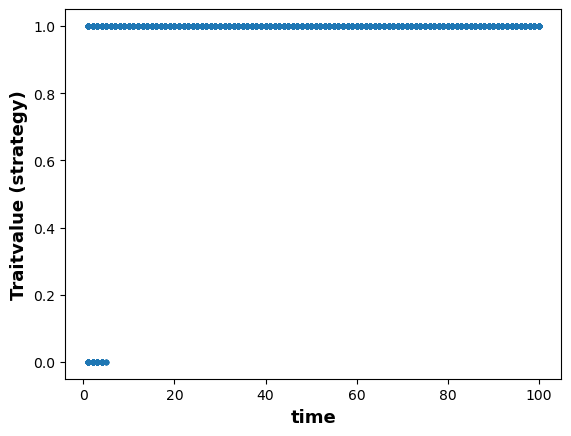

In [13]:
run(100,1)

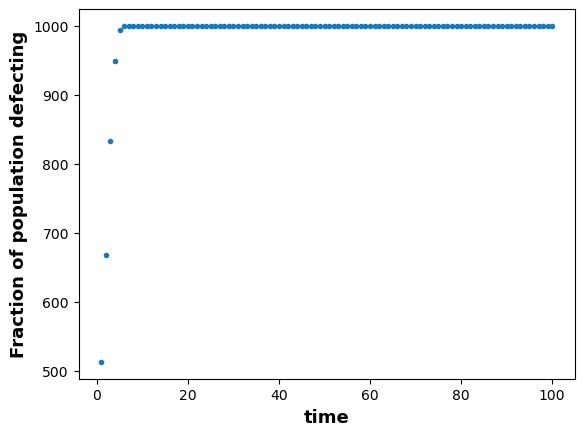

In [14]:
plotFractions(100,1)